# Task 3: Customer Churn Prediction (Bank Customers)

## Introduction & Problem Statement

**Customer churn** occurs when customers stop doing business with a company. In banking, retaining existing customers is significantly cheaper than acquiring new ones, making churn prediction a critical business priority.

**Objective:** Build a classifier to predict whether a bank customer will **churn (`Exited = 1`)** or **stay (`Exited = 0`)**, and identify the key drivers of churn.

**Dataset:** `task3_dataset.csv` — 10,000 real bank customers (Churn Modelling Dataset)

| Feature | Description |
|---|---|
| `CreditScore` | Customer credit score |
| `Geography` | Country: France / Germany / Spain |
| `Gender` | Male / Female |
| `Age` | Customer age |
| `Tenure` | Years with the bank |
| `Balance` | Account balance |
| `NumOfProducts` | Number of bank products held |
| `HasCrCard` | Has credit card (1/0) |
| `IsActiveMember` | Active member (1/0) |
| `EstimatedSalary` | Estimated annual salary |
| `Exited` | **Target** — 1 = Churned, 0 = Retained |

## 1. Import Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
%matplotlib inline
print('Libraries loaded!')

Libraries loaded!


## 2. Dataset Understanding & Description

In [26]:
# Load the dataset
df = pd.read_csv('task3_dataset.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Shape: (10000, 14)
Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [27]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [29]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [30]:
print('Target distribution:')
print(df['Exited'].value_counts())
print(f'\nChurn rate: {df["Exited"].mean()*100:.2f}%')

Target distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn rate: 20.37%


## 3. Data Cleaning & Preparation

In [31]:
# Check missing values
print('Missing values:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0


In [32]:
# Drop non-predictive identifier columns
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Binary encode Gender using Label Encoding
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Female=0, Male=1
print('Gender encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# One-Hot Encode Geography (3 categories) — drop first to avoid multicollinearity
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

print('\nColumns after encoding:', df.columns.tolist())
df.head(3)

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}

Columns after encoding: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False


## 4. Exploratory Data Analysis (EDA)

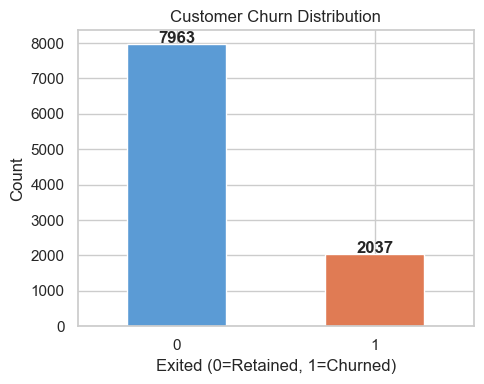

In [33]:
# Churn distribution
plt.figure(figsize=(5, 4))
ax = df['Exited'].value_counts().sort_index().plot(
    kind='bar', color=['#5B9BD5', '#E07B54'], edgecolor='white', width=0.5
)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 30),
                ha='center', fontweight='bold')
plt.title('Customer Churn Distribution')
plt.xlabel('Exited (0=Retained, 1=Churned)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

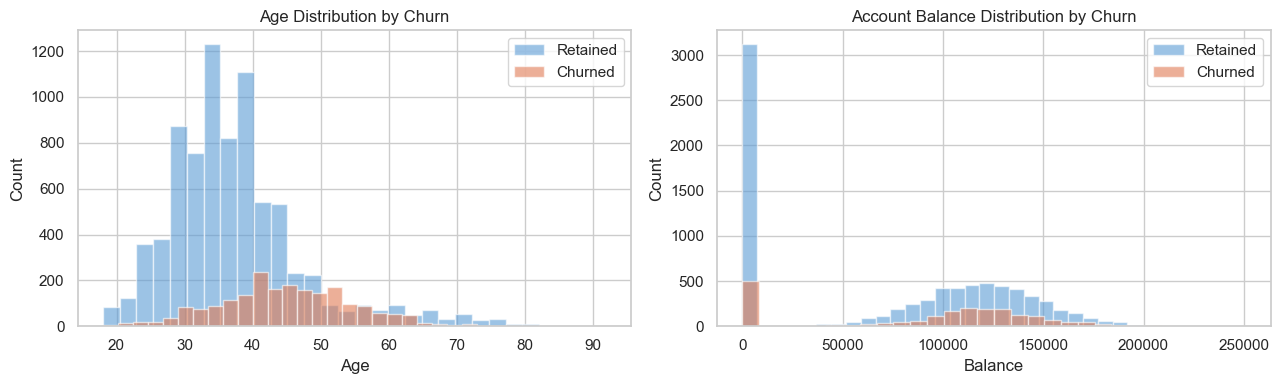

In [34]:
# Age and Balance distributions by churn
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for val, label, color in [(0, 'Retained', '#5B9BD5'), (1, 'Churned', '#E07B54')]:
    axes[0].hist(df[df['Exited']==val]['Age'], bins=30,
                 alpha=0.6, label=label, color=color, edgecolor='white')
    axes[1].hist(df[df['Exited']==val]['Balance'], bins=30,
                 alpha=0.6, label=label, color=color, edgecolor='white')

axes[0].set_title('Age Distribution by Churn')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count'); axes[0].legend()
axes[1].set_title('Account Balance Distribution by Churn')
axes[1].set_xlabel('Balance'); axes[1].set_ylabel('Count'); axes[1].legend()
plt.tight_layout()
plt.show()

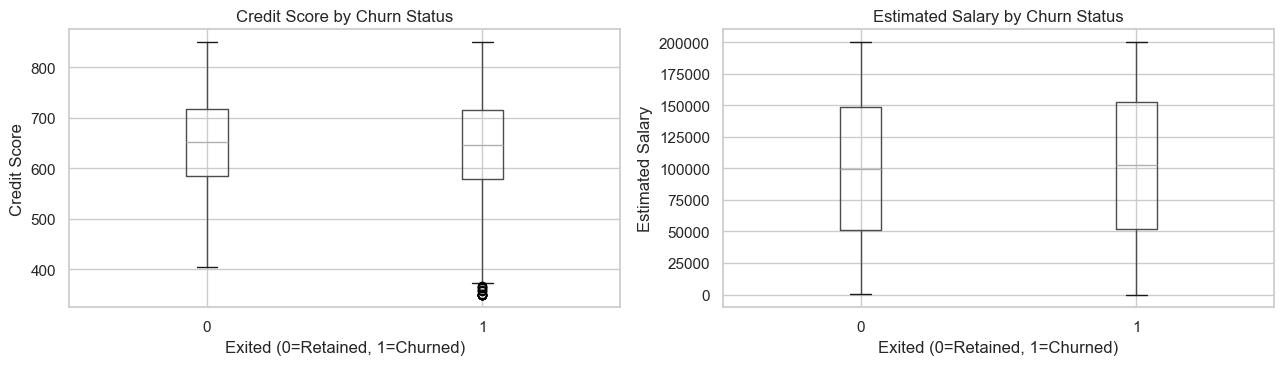

In [35]:
# Box plots: CreditScore and EstimatedSalary by churn
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.boxplot(column='CreditScore', by='Exited', ax=axes[0])
axes[0].set_title('Credit Score by Churn Status')
axes[0].set_xlabel('Exited (0=Retained, 1=Churned)')
axes[0].set_ylabel('Credit Score')

df.boxplot(column='EstimatedSalary', by='Exited', ax=axes[1])
axes[1].set_title('Estimated Salary by Churn Status')
axes[1].set_xlabel('Exited (0=Retained, 1=Churned)')
axes[1].set_ylabel('Estimated Salary')

plt.suptitle('')
plt.tight_layout()
plt.show()

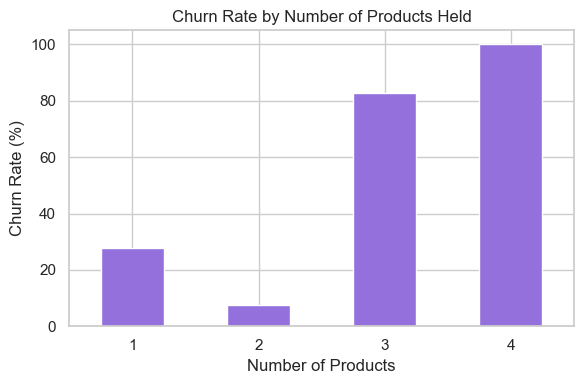

In [36]:
# Churn rate by number of products
plt.figure(figsize=(6, 4))
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
prod_churn.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Churn Rate by Number of Products Held')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

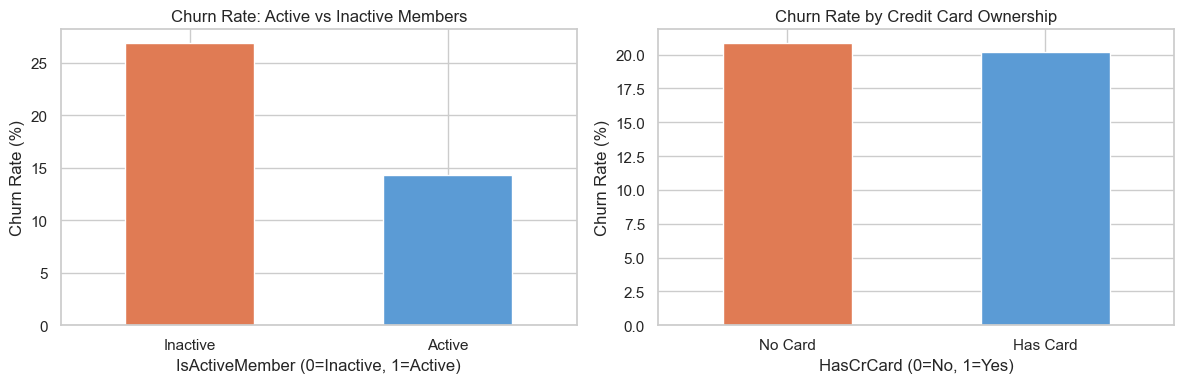

In [37]:
# Churn rate by IsActiveMember and HasCrCard
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
active_churn.plot(kind='bar', ax=axes[0], color=['#E07B54', '#5B9BD5'], edgecolor='white')
axes[0].set_title('Churn Rate: Active vs Inactive Members')
axes[0].set_xlabel('IsActiveMember (0=Inactive, 1=Active)')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xticklabels(['Inactive', 'Active'], rotation=0)

card_churn = df.groupby('HasCrCard')['Exited'].mean() * 100
card_churn.plot(kind='bar', ax=axes[1], color=['#E07B54', '#5B9BD5'], edgecolor='white')
axes[1].set_title('Churn Rate by Credit Card Ownership')
axes[1].set_xlabel('HasCrCard (0=No, 1=Yes)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(['No Card', 'Has Card'], rotation=0)

plt.tight_layout()
plt.show()

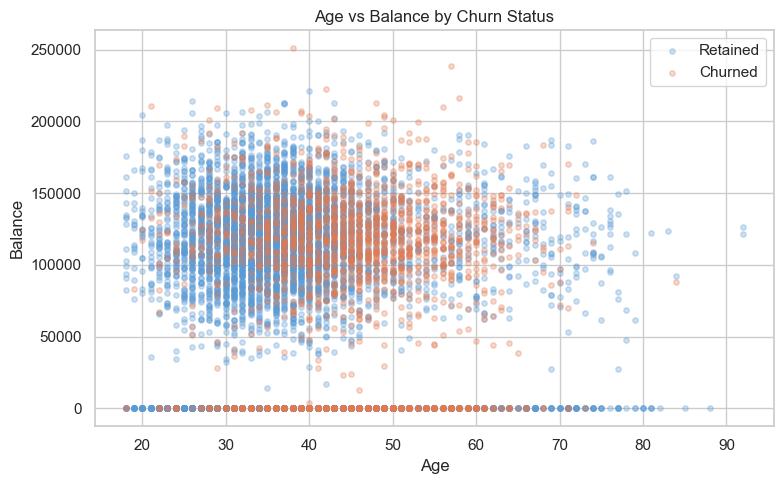

In [38]:
# Scatter: Age vs Balance coloured by churn
plt.figure(figsize=(8, 5))
for val, label, color in [(0, 'Retained', '#5B9BD5'), (1, 'Churned', '#E07B54')]:
    sub = df[df['Exited'] == val]
    plt.scatter(sub['Age'], sub['Balance'], alpha=0.3, s=15, label=label, color=color)
plt.title('Age vs Balance by Churn Status')
plt.xlabel('Age'); plt.ylabel('Balance')
plt.legend()
plt.tight_layout()
plt.show()

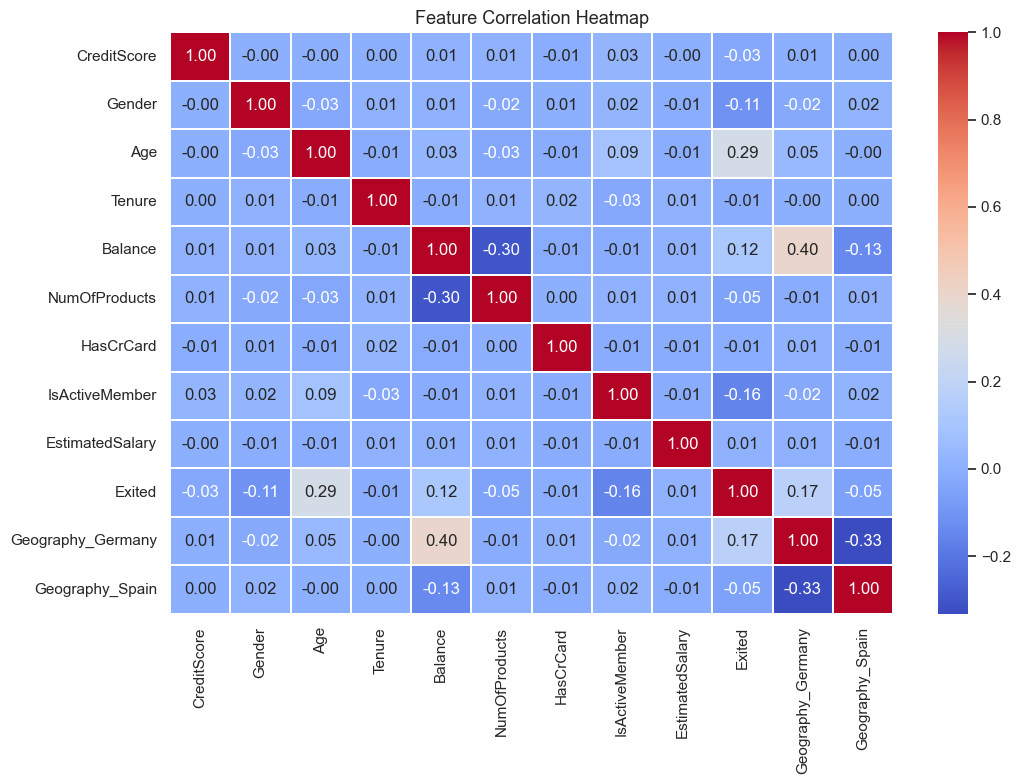

In [39]:
# Correlation heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.3)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Model Training & Testing

In [40]:
X = df.drop(columns=['Exited'])
y = df['Exited']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 8000 | Test: 2000


In [41]:
# Random Forest — strong baseline for tabular classification
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print('Random Forest trained!')

Random Forest trained!


## 6. Evaluation Metrics

In [42]:
acc = accuracy_score(y_test, y_pred_rf)
auc = roc_auc_score(y_test, y_prob_rf)
print(f'Accuracy : {acc:.4f} ({acc*100:.2f}%)')
print(f'ROC-AUC  : {auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Retained', 'Churned']))

Accuracy : 0.8650 (86.50%)
ROC-AUC  : 0.8637

Classification Report:
              precision    recall  f1-score   support

    Retained       0.87      0.97      0.92      1593
     Churned       0.81      0.44      0.57       407

    accuracy                           0.86      2000
   macro avg       0.84      0.71      0.74      2000
weighted avg       0.86      0.86      0.85      2000



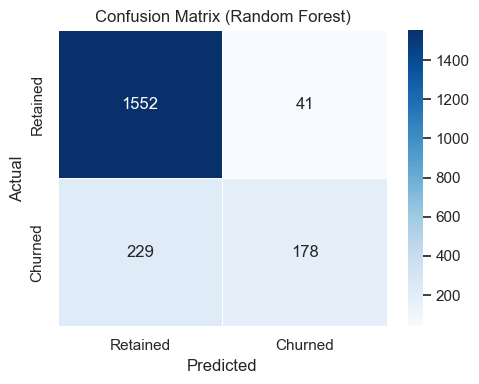

In [43]:
# Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'], linewidths=0.5)
plt.title('Confusion Matrix (Random Forest)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()

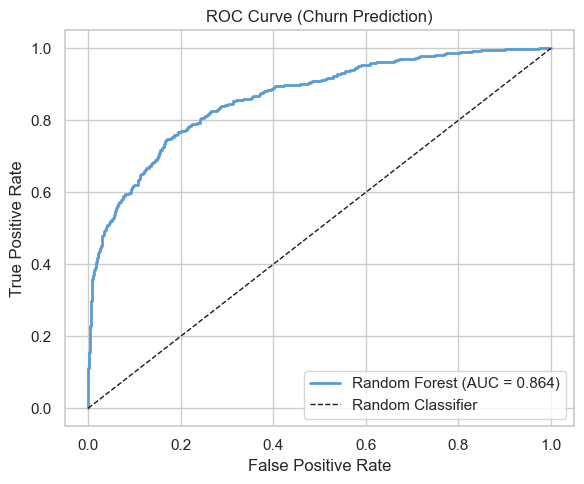

In [44]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#5B9BD5', lw=2, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Churn Prediction)')
plt.legend()
plt.tight_layout()
plt.show()

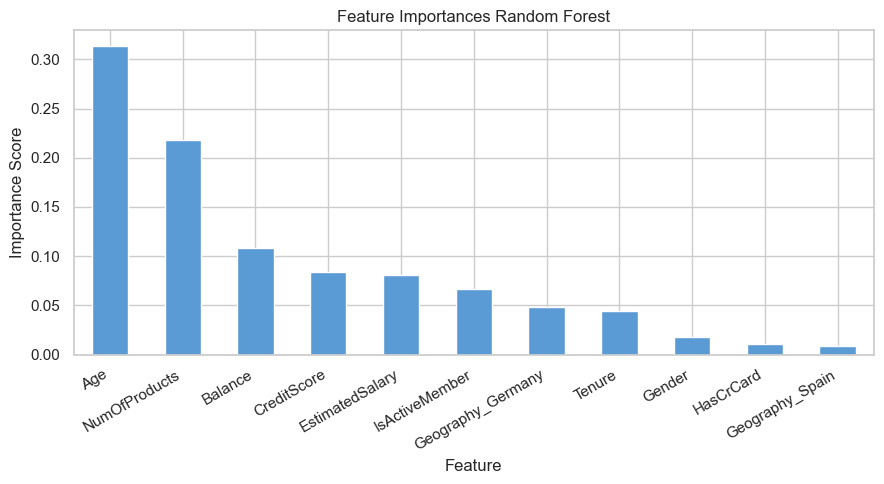

Top 5 Features:
Age                0.3137
NumOfProducts      0.2178
Balance            0.1084
CreditScore        0.0838
EstimatedSalary    0.0809


In [47]:
# Feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(9, 5))
importances.plot(kind='bar', color='#5B9BD5', edgecolor='white')
plt.title('Feature Importances Random Forest')
plt.xlabel('Feature'); plt.ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print('Top 5 Features:')
print(importances.head().round(4).to_string())

In [46]:
# 5-Fold Cross-Validation
cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    X_scaled, y, cv=5, scoring='roc_auc', n_jobs=-1
)
print(f'5-Fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-Fold CV ROC-AUC: 0.8606 ± 0.0042


## 7. Conclusion

### Key Insights:

1. **Churn rate is 20.37%**; 2,037 out of 10,000 customers churned, creating a moderate class imbalance.
2. **Age** is the top predictor; older customers (40–60) churn at significantly higher rates than younger ones.
3. **Balance** shows a bimodal distribution ; customers with zero balance or very high balance both show elevated churn risk.
4. **Number of Products** has a striking non-linear effect ; customers with 3–4 products churn far more than those with 1–2.
5. **Inactive members** churn at nearly double the rate of active members ; a key retention signal.
6. **Germany** (`Geography_Germany = 1`) shows higher churn rates than France or Spain.
7. **Gender** (Female) slightly correlates with higher churn in this dataset.
8. **Label Encoding** was used for Gender; **One-Hot Encoding** for Geography ; the appropriate choice for each cardinality.

**Business Recommendation:** Target retention campaigns at older, inactive customers ; particularly those in Germany holding 3+ products.